# V0 sandbox — Notebook 1 of 3: 18S coloring (transcripts → per-pixel lineage)

## The problem

Cellpose-SAM sometimes segments a doublet — two adjacent cells of different lineages — as a **single** mask. We want to fix this by modifying the 18S channel before segmentation: introducing a dim "cut" along the heterotypic boundary so CP-SAM has a chance to find it.

To find the boundary inside a doublet we need to know what lineage each pixel belongs to. **That is what this notebook produces.** Inputs: raw transcripts + 18S morphology. Output: a per-pixel lineage posterior.

## V0 pipeline architecture

```
NB 1 (this):     transcripts + 18S       →  per-pixel lineage posterior π_abst         ← YOU ARE HERE
NB 2 (boundary): π_abst                  →  binary boundary mask
NB 3 (cutting):  boundary mask + 18S    →  cut field  →  Cellpose-SAM
```

Outputs this notebook hands to NB 2: `pi_abst`, `confidence`, `N_eff`. Nothing else.

## Constraint

Everything in this notebook must be **segmentation-agnostic** — never use a prior CP-SAM mask, a doublet table, or any per-cell label as an input. (We DO load the existing WSI mask, but only to define the yellow focal-cell contour for evaluation — never to feed it into the analysis.)

## Test doublet

**DB_top100_031** — Fibroblast × Melanoma, with bright 18S (top-50% median ≈ 1275). Picked as the highest-brightness Fib×Mel in our 68-doublet dev set so the visualisations are legible. ROI is **384 × 384 px** centred on the focal cell — no CP-SAM here, so no need for the 2048 px context that NB 3 uses.

## Glossary

| Term | Definition |
|---|---|
| **anchor** | A transcript whose gene is a lineage-specific marker, positioned at its pixel. A "vote" for one of K=7 lineages at a sub-pixel location. |
| **lineage** | One of K=7 cell-type categories in this skin panel: Melanoma, Myeloid, Tcell, Plasma, Fibroblast, Endothelial, Keratinocyte. |
| **N_eff_k(x)** | Effective count of lineage-k anchors at pixel x after spatial smoothing. |
| **N_total(x)** | Σ_k N_eff_k(x). |
| **π_abst(x)** | Per-pixel posterior over lineages, K-dim vector summing to 1. The main output of this notebook. |
| **confidence(x)** | N_total / (N_total + N_min) ∈ [0, 1]. Trust in the lineage call at x. |
| **cell_evidence(x)** | max(DAPI_n, 18S_n) — morphology-only "is there a cell here?" gate. |
| **argmax(π)(x)** | Per-pixel dominant lineage label (for visualisation). |
| **margin(x)** | π_top1 − π_top2 — decisiveness of the lineage call. |
| **doublet** | A CP-SAM mask that should have been two cells (different lineages) but came out as one. |
| **focal cell** | The doublet candidate under inspection. Yellow contour in every figure. |
| **K** | 7 lineages in this panel. |

## Visual conventions

- **Yellow contour**: focal cell footprint from the existing WSI CP-SAM mask. Eval reference only — never feeds the analysis.
- **Colored dots**: anchor positions, color by lineage (`V0_LINEAGE_COLORS`):
  - Mel=blue · Myeloid=orange · Tcell=green · Plasma=red · **Fib=yellow** · Endo=brown · Kerat=pink
  - Fib is yellow (NOT purple) so Mel↔Fib boundary blend renders green-ish, not ambiguous blue-purple.
- **Colored 18S**: per-pixel lineage-weighted color blend × 18S brightness. Low confidence → grayscale 18S (NOT muddy mean-of-colors).
- **Lime contour** (when shown): π sign-change line — informational reference.
- **Input → output discipline**: every figure shows the inputs adjacent to or overlaid on the output. Hard project rule.

In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
REPO = Path.cwd().parents[0]
sys.path.insert(0, str(REPO / "pipelines" / "V0"))
import numpy as np, pandas as pd, tifffile, matplotlib.pyplot as plt, zarr
from matplotlib.colors import ListedColormap
from scipy.ndimage import gaussian_filter
from skimage.segmentation import find_boundaries
import lib

print(f"V0 constants from lib.py:")
print(f"  K = {lib.K} lineages: {lib.LINEAGES}")
print(f"  pixel size: {lib.PIXEL_UM} µm/px")
print(f"  σ_diffuse: {lib.SIGMA_UM} µm = {lib.SIGMA_DIFFUSE_PX:.3f} px")
print(f"  Dirichlet α = {lib.ALPHA}")
print(f"  grey-abstain N_min = {lib.N_MIN}")
print(f"  qv threshold ≥ {lib.QV_MIN}")

V0 constants from lib.py:
  K = 7 lineages: ['Melanoma', 'Myeloid', 'Tcell', 'Plasma', 'Fibroblast', 'Endothelial', 'Keratinocyte']
  pixel size: 0.2125 µm/px
  σ_diffuse: 2.0 µm = 9.412 px
  Dirichlet α = 10.0
  grey-abstain N_min = 3.0
  qv threshold ≥ 20.0


In [2]:
# Load ROI 018 + WSI focal-cell footprint (eval reference; never enters posterior math)
BENCHMARK_ID = "DB_top100_031"  # brighter 18S; was 018 (top-50% median 1275 vs 566)
CROP_PX = 384                   # focused ROI; NB 1/2 do not run CP-SAM, so no need for the full 2048 context
ZOOM_PAD = 30                   # tighter zoom inside the focused ROI
bench = pd.read_parquet(lib.DATA / "benchmark_doublets.parquet")
row = bench[bench.benchmark_id == BENCHMARK_ID].iloc[0]
cx, cy = float(row.x_um), float(row.y_um); cps_focal = int(row.cps_id_at_bookmark)
lin_a, lin_b = row.lineage_pair.split(" × ")
ka, kb = lib.LIN_TO_IDX[lin_a], lib.LIN_TO_IDX[lin_b]
with tifffile.TiffFile(lib.DAPI_TIF) as tf: wsi_H, wsi_W = tf.series[0].shape[-2:]
y0, y1, x0, x1 = lib.make_roi_bbox_centred(cx, cy, CROP_PX, wsi_H, wsi_W)
dapi, s18 = lib.load_morphology(y0, y1, x0, x1)
H, W = s18.shape

wsi_mask_full = tifffile.imread(lib.DATA / "cpsam_whole_slide" / "masks.tif")
focal = (wsi_mask_full[y0:y1, x0:x1] == cps_focal); del wsi_mask_full
ys, xs = np.where(focal)
zy0 = max(int(ys.min())-ZOOM_PAD, 0); zy1 = min(int(ys.max())+ZOOM_PAD, H)
zx0 = max(int(xs.min())-ZOOM_PAD, 0); zx1 = min(int(xs.max())+ZOOM_PAD, W)
zoom = (slice(zy0, zy1), slice(zx0, zx1))
focal_z = focal[zoom]
vmax_dapi = float(np.percentile(dapi, 99))
vmax_s18  = float(np.percentile(s18, 99))
print(f"ROI 2048: y=[{y0},{y1}] x=[{x0},{x1}]; focal cell {cps_focal}: {focal.sum()} px ({lin_a} × {lin_b})")

<tifffile.TiffFile 'morphology_focus_0000.ome.tif'> OME series cannot read multi-file pyramids


ROI 2048: y=[238,622] x=[40340,40724]; focal cell 782: 3048 px (Fibroblast × Melanoma)


## Stage 1 — Gene → lineage label map

Reads `gene_labels_lineage.parquet` and emits an int8 array of length `n_genes` mapping each gene to a lineage index (or -1 for ambiguous / not in panel). Validation: known marker genes must map to the expected lineage.

In [3]:
gene_lin = lib.load_lineage_label_map()
gene_names = list(zarr.open(lib.TX_ZARR, mode="r").attrs["gene_names"])

print(f"panel: {len(gene_names)} genes total")
print(f"  lineage-mapped (non-ambiguous): {(gene_lin >= 0).sum()} genes")
for k, L in enumerate(lib.LINEAGES):
    print(f"    {k} {L:13s}: {(gene_lin == k).sum()} genes")

# Sanity: known marker genes
gene_to_idx = {g: i for i, g in enumerate(gene_names)}
checks = [("MITF", "Melanoma"), ("CD3E", "Tcell"), ("CD79A", "Plasma"),
           ("CD14", "Myeloid"), ("PECAM1", "Endothelial")]
print("\nMarker-gene sanity check:")
for g, expected in checks:
    if g not in gene_to_idx:
        print(f"  {g}: not in panel — skip"); continue
    k_actual = int(gene_lin[gene_to_idx[g]])
    got = lib.LINEAGES[k_actual] if k_actual >= 0 else "ambiguous"
    ok = got == expected
    print(f"  {g}: expected={expected}, got={got}  {'✓' if ok else '✗'}")

panel: 10017 genes total
  lineage-mapped (non-ambiguous): 1397 genes
    0 Melanoma     : 155 genes
    1 Myeloid      : 171 genes
    2 Tcell        : 156 genes
    3 Plasma       : 114 genes
    4 Fibroblast   : 218 genes
    5 Endothelial  : 250 genes
    6 Keratinocyte : 333 genes

Marker-gene sanity check:
  MITF: expected=Melanoma, got=Melanoma  ✓
  CD3E: expected=Tcell, got=Tcell  ✓
  CD79A: expected=Plasma, got=Plasma  ✓
  CD14: expected=Myeloid, got=Myeloid  ✓
  PECAM1: expected=Endothelial, got=Endothelial  ✓


## Stage 2 — Anchor extraction

Iterate the 250 µm transcript grid tiles overlapping the ROI bbox. Keep transcripts with `qv ≥ 20`, `valid == 1`, and a lineage-mapped gene. Convert to pixel coordinates in the **crop frame**.

In [4]:
py, px, li = lib.load_anchors_in_bbox(y0, y1, x0, x1, gene_lin)
print(f"anchors in 2048 ROI: {len(py):,}")
for k, L in enumerate(lib.LINEAGES):
    print(f"  {L}: {int((li==k).sum()):,}")

# Sanity: do anchors land on cellular pixels (brighter 18S)?
rng = np.random.default_rng(0)
rand_y = rng.integers(0, H, len(py)); rand_x = rng.integers(0, W, len(py))
print(f"\nspatial alignment with 18S:")
print(f"  mean 18S at anchor pixels:  {s18[py, px].mean():.0f}")
print(f"  mean 18S at random pixels:  {s18[rand_y, rand_x].mean():.0f}")
print(f"  ratio: {s18[py, px].mean() / max(s18[rand_y, rand_x].mean(), 1):.2f}x  (expect ≳1.5 for cytoplasmic transcripts)")
print(f"\nanchors INSIDE focal cell {cps_focal}: {int(focal[py, px].sum())}")
in_f = focal[py, px]
for k, L in enumerate(lib.LINEAGES):
    n = int(((li == k) & in_f).sum())
    if n: print(f"  {L}: {n}")

anchors in 2048 ROI: 6,938
  Melanoma: 3,611
  Myeloid: 365
  Tcell: 366
  Plasma: 540
  Fibroblast: 1,075
  Endothelial: 389
  Keratinocyte: 592

spatial alignment with 18S:
  mean 18S at anchor pixels:  1188
  mean 18S at random pixels:  936
  ratio: 1.27x  (expect ≳1.5 for cytoplasmic transcripts)

anchors INSIDE focal cell 782: 303
  Melanoma: 124
  Myeloid: 11
  Plasma: 11
  Fibroblast: 118
  Endothelial: 18
  Keratinocyte: 21


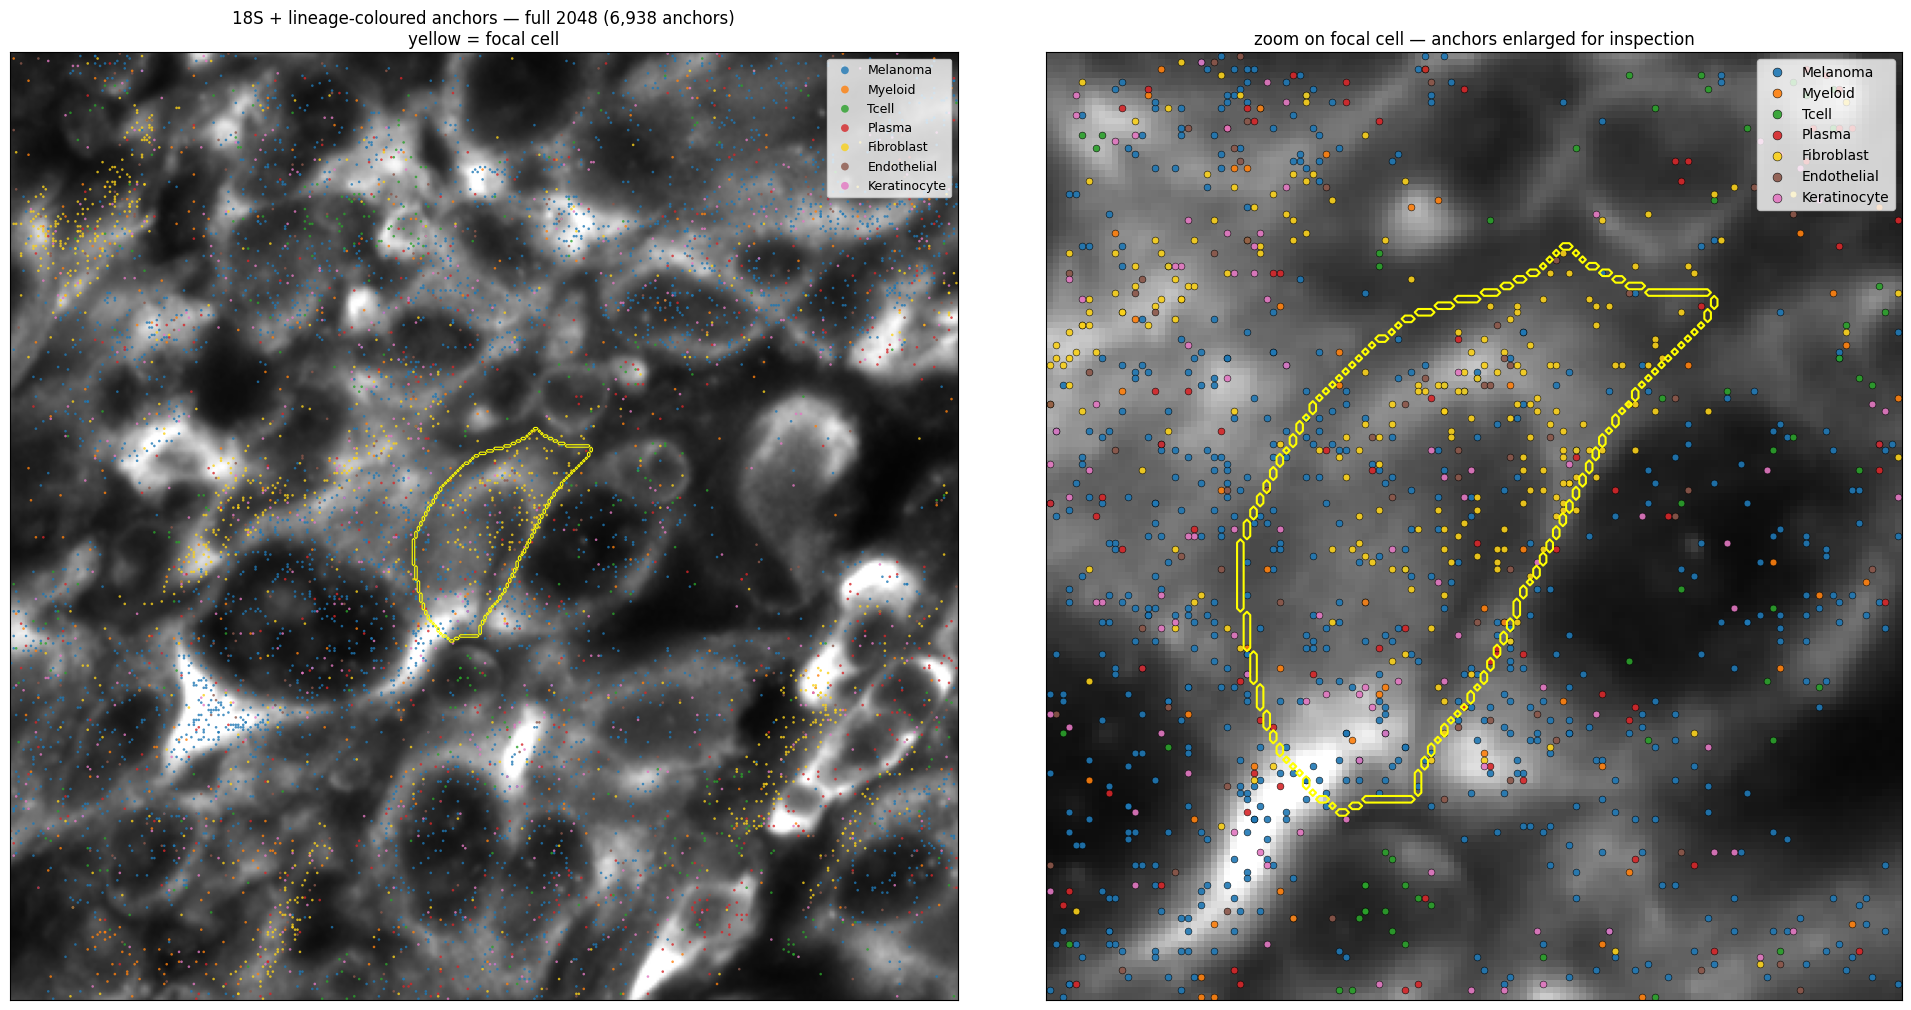

In [5]:
# Visual: colored anchors on raw 18S — full 2048 + zoom on focal
LIN_COLORS = lib.V0_LINEAGE_COLORS
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].imshow(s18, cmap="gray", vmin=0, vmax=vmax_s18)
for k, L in enumerate(lib.LINEAGES):
    m = li == k
    if m.any():
        axes[0].scatter(px[m], py[m], s=3.5, color=LIN_COLORS[k], edgecolors="none", alpha=0.8, label=L)
axes[0].contour(find_boundaries(focal, mode="outer").astype(int), levels=[0.5], colors="yellow", linewidths=0.8)
axes[0].set_title(f"18S + lineage-coloured anchors — full 2048 ({len(py):,} anchors)\nyellow = focal cell")
axes[0].legend(loc="upper right", fontsize=9, markerscale=3)
axes[1].imshow(s18[zoom], cmap="gray", vmin=0, vmax=vmax_s18)
in_z = (py >= zy0) & (py < zy1) & (px >= zx0) & (px < zx1)
for k, L in enumerate(lib.LINEAGES):
    m = in_z & (li == k)
    if m.any():
        axes[1].scatter(px[m] - zx0, py[m] - zy0, s=24, color=LIN_COLORS[k],
                        edgecolors="black", linewidths=0.4, alpha=0.9, label=L)
axes[1].contour(find_boundaries(focal_z, mode="outer").astype(int), levels=[0.5], colors="yellow", linewidths=1.5)
axes[1].set_title("zoom on focal cell — anchors enlarged for inspection")
axes[1].legend(loc="upper right", fontsize=10, markerscale=1.3)
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## Stage 3 — Per-lineage anchor density (Gaussian-smoothed)

For each lineage k: bin anchors to integer pixel positions, then convolve with isotropic Gaussian σ_diffuse = 2 µm (≈ 9.4 px). The effective per-pixel anchor count is `N_eff_k = 2π σ² · ρ_k(x)` — calibrated so each anchor contributes ~1 unit mass to its smoothed neighbourhood.

In [6]:
K = lib.K
rho_pts = np.zeros((K, H, W), dtype=np.float32)
np.add.at(rho_pts, (li, py, px), 1.0)
rho_smooth = np.stack([gaussian_filter(rho_pts[k], sigma=lib.SIGMA_DIFFUSE_PX, mode="reflect")
                        for k in range(K)], axis=0)
N_eff   = rho_smooth * 2.0 * np.pi * lib.SIGMA_DIFFUSE_PX ** 2
N_total = N_eff.sum(axis=0)

print("Per-lineage N_eff (effective anchor count per pixel after smoothing):")
print(f"{'lineage':14s} | {'max':>6s} | {'mean':>6s} | {'p95':>6s} | n_anchors")
for k, L in enumerate(lib.LINEAGES):
    nk = int((li == k).sum())
    print(f"{L:14s} | {N_eff[k].max():6.2f} | {N_eff[k].mean():6.3f} | {np.percentile(N_eff[k], 95):6.3f} | {nk:,}")
print(f"\nN_total: max={N_total.max():.2f}, mean={N_total.mean():.3f}, p95={np.percentile(N_total, 95):.3f}")

Per-lineage N_eff (effective anchor count per pixel after smoothing):
lineage        |    max |   mean |    p95 | n_anchors
Melanoma       |  62.34 | 13.630 | 32.986 | 3,611
Myeloid        |  15.43 |  1.378 |  3.495 | 365
Tcell          |  18.30 |  1.381 |  5.226 | 366
Plasma         |  17.61 |  2.038 |  5.536 | 540
Fibroblast     |  56.62 |  4.058 | 20.808 | 1,075
Endothelial    |   7.50 |  1.468 |  3.818 | 389
Keratinocyte   |   8.53 |  2.235 |  5.335 | 592

N_total: max=77.61, mean=26.187, p95=52.412


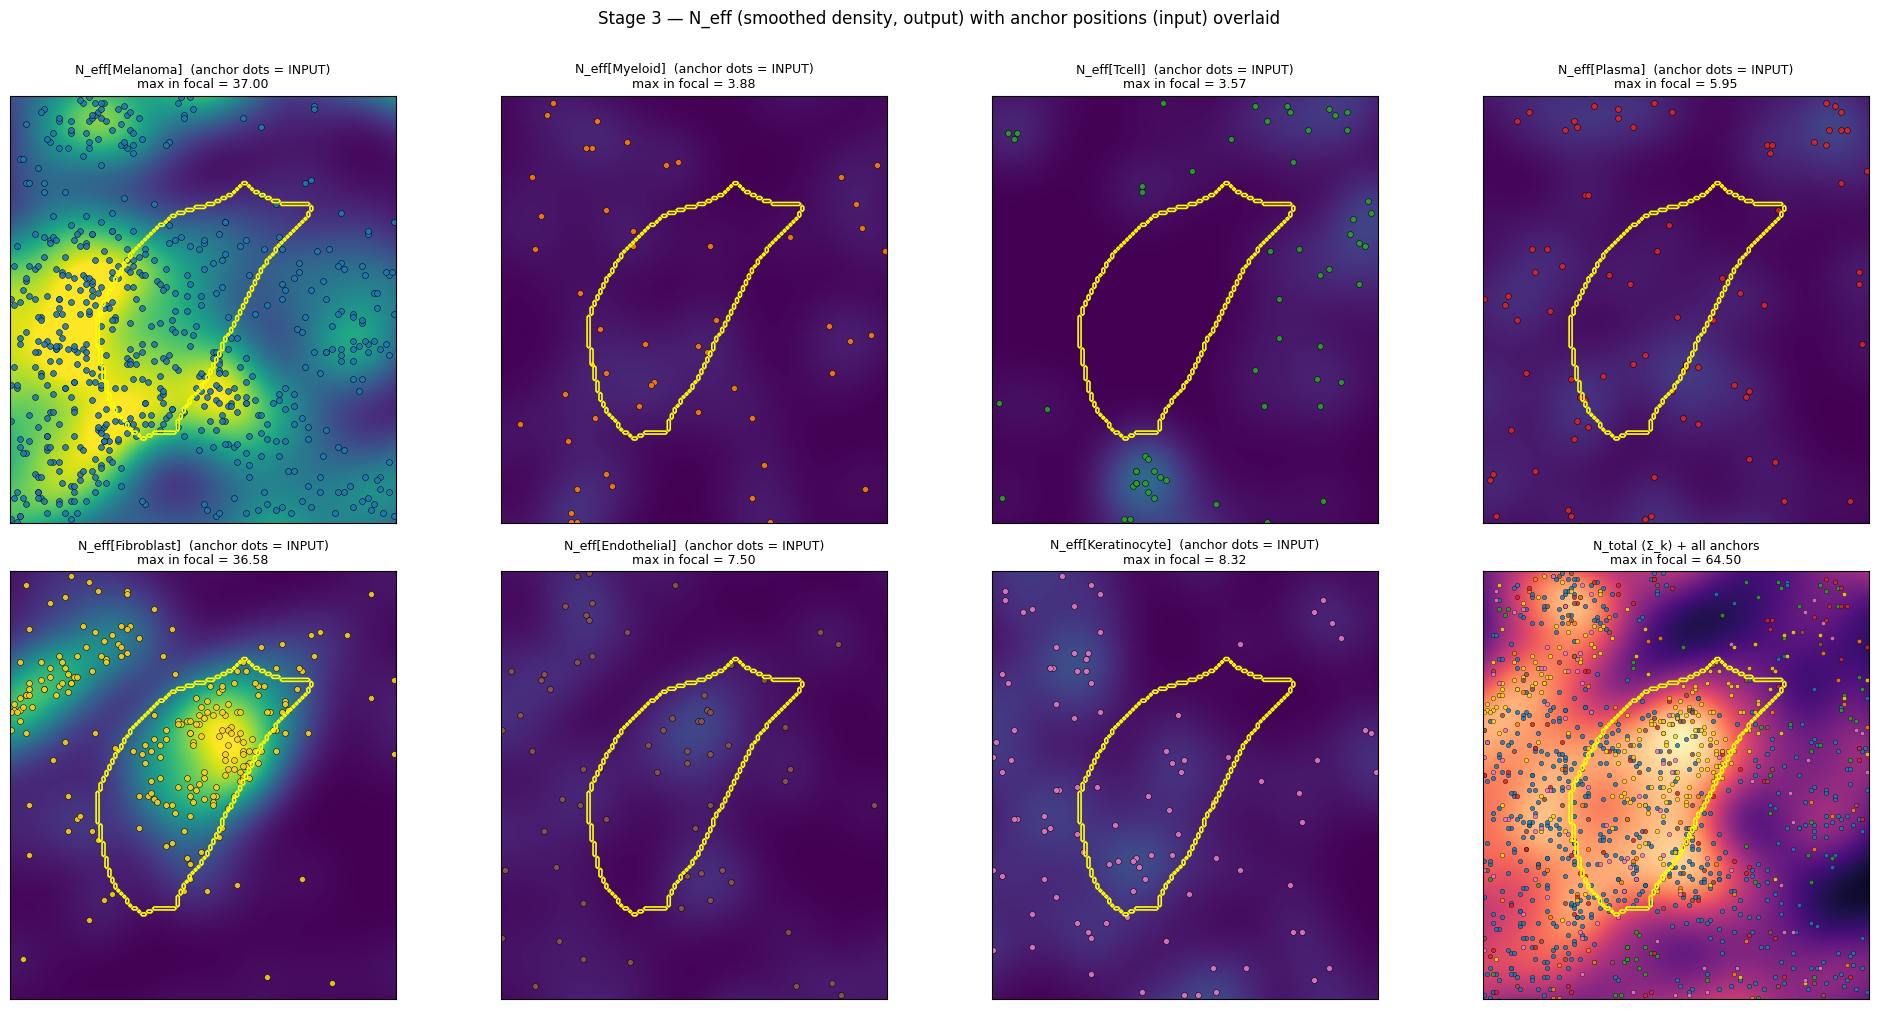

In [7]:
# Per-lineage N_eff grid — INPUT (anchor dots) overlaid on OUTPUT (smoothed density)
LIN_COLORS = lib.V0_LINEAGE_COLORS
in_z = (py >= zy0) & (py < zy1) & (px >= zx0) & (px < zx1)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
vmax_ne = float(np.percentile(N_eff, 99.5))
for k in range(K):
    ax = axes.ravel()[k]
    ax.imshow(N_eff[k][zoom], cmap="viridis", vmin=0, vmax=vmax_ne)
    # OVERLAY: the lineage-k anchor positions that produced this density (input → output)
    m = in_z & (li == k)
    if m.any():
        ax.scatter(px[m] - zx0, py[m] - zy0, s=18, color=LIN_COLORS[k],
                    edgecolors="black", linewidths=0.4, alpha=0.9)
    ax.contour(find_boundaries(focal_z, mode="outer").astype(int), levels=[0.5], colors="yellow", linewidths=1.2)
    ax.set_title(f"N_eff[{lib.LINEAGES[k]}]  (anchor dots = INPUT)\nmax in focal = {N_eff[k][focal].max():.2f}", fontsize=9)
axes[1,3].imshow(N_total[zoom], cmap="magma", vmin=0, vmax=float(np.percentile(N_total, 99.5)))
for k in range(K):
    m = in_z & (li == k)
    if m.any():
        axes[1,3].scatter(px[m] - zx0, py[m] - zy0, s=10, color=LIN_COLORS[k],
                           edgecolors="black", linewidths=0.3, alpha=0.85)
axes[1,3].contour(find_boundaries(focal_z, mode="outer").astype(int), levels=[0.5], colors="yellow", linewidths=1.2)
axes[1,3].set_title(f"N_total (Σ_k) + all anchors\nmax in focal = {N_total[focal].max():.2f}", fontsize=9)
for ax in axes.ravel(): ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Stage 3 — N_eff (smoothed density, output) with anchor positions (input) overlaid",
             fontsize=12, y=1.005)
plt.tight_layout(); plt.show()


## Stage 3b — Smoothing kernel sweep (Gaussian KDE vs anisotropic diffusion, multi-σ)

**The single biggest choice in the coloring layer:** what kernel turns sparse anchor points into per-pixel densities? Two families:

1. **Isotropic Gaussian KDE** — `scipy.ndimage.gaussian_filter`; doesn't know where cells are; leaks across cell gaps.
2. **Anisotropic diffusion** — `lib.diffuse_anisotropic`; per-edge conductance = `c(p) · c(q)` with `c = make_conductance(s18, mode="linear")` (= 1-99 percentile clip of 18S to [0, 1]); anchor information flows along bright cytoplasm, blocked at dim gaps.

**σ sweep:** {0.5, 1.0, 2.0, 4.0} µm. Effective `σ_eff_px = sqrt(n_iter · dt)`, so anisotropic n_iter = `(σ_px)² / dt`. For each σ we paint a per-pixel coloured tissue map: posterior-weighted lineage colour × 18S brightness × confidence; low-confidence pixels fall back to grayscale 18S.

**Weighting scheme** (matches the original `tint_cytoplasm_diffusion` pipeline):
```
rho_smoothed = KERNEL(rho_points)                        # Gaussian or anisotropic
N_eff_k    = 2π · σ_eff² · rho_smoothed[k]              # effective per-pixel count
N_total    = Σ_k N_eff_k
pi_ml[k]   = N_eff_k / N_total                          # max-likelihood posterior (no Dirichlet α here — simpler weighting for tint)
c          = N_total / (N_total + N_min)                # confidence ∈ [0, 1]; N_min = 3
color(x)   = Σ_k pi_ml[k] · LIN_COLORS[k]               # weighted lineage colour
tinted(x)  = color · s18_n · c + (s18_n, s18_n, s18_n) · (1 − c)
```

Row 0: reference 18S+anchors AND Gaussian KDE at 4 σ. Row 1: conductance map AND anisotropic diffusion at 4 σ_eff.
Labels `(under)` / `← sweet` / `(at design)` / `(over)` are heuristic — pick what looks right for this ROI.

### Method note — calibrating `n_iter` for the conductance

For 4-connected anisotropic diffusion with per-edge conductance `c(p)·c(q)`, the effective σ at a pixel scales as

```
σ_eff_px ≈ sqrt(n_iter · dt · c²(local))
```

Naive calibration `n_iter = σ_target² / dt` assumes `c=1` everywhere (impossible with the 1-99 percentile clip). Inside cells, `c ≈ 0.4-0.5` → `c² ≈ 0.2-0.25` → diffusion runs **~5× slower** than nominal. **Symptom**: anchors stay punctate even after `n_iter=443` iterations.

**Fix in `lib.py`**: `N_ITER_ANISO = (1 / ANISO_TYPICAL_C2) · σ_px² / dt`, with `ANISO_TYPICAL_C2 = 0.25`. So at σ_target = 2 µm, `n_iter ≈ 1772` instead of 443. The diffusion now achieves σ_eff ≈ σ_target IN TYPICAL CELL INTERIORS, while staying low-σ in dim regions (the desired anisotropy). Tune `ANISO_TYPICAL_C2` if cells still look under-spread.

In [8]:
import time
from scipy.ndimage import gaussian_filter

# Sigmas to sweep (in µm)
SIGMAS_UM = [0.5, 1.0, 2.0, 4.0]
SIGMA_LABELS = ["(under)", "← sweet", "(at design)", "(over)"]
N_MIN = lib.N_MIN

# Conductance from 18S (linear 1-99 percentile clip)
cond = lib.make_conductance(s18, mode="linear")
print(f"conductance: mean={cond.mean():.3f}, fraction > 0.5 = {(cond > 0.5).mean()*100:.1f}%")

# Build per-lineage anchor density (point mass) once
rho_pts = np.zeros((lib.K, H, W), dtype=np.float32)
np.add.at(rho_pts, (li, py, px), 1.0)

def tinted_18s(rho_smoothed, sigma_eff_px, lineage_colors, s18_raw, percentiles):
    """Posterior-weighted tinted 18S (matches the original tint_cytoplasm pipeline)."""
    N_eff_local = rho_smoothed * 2.0 * np.pi * sigma_eff_px ** 2
    N_tot       = N_eff_local.sum(0)
    pi_ml       = N_eff_local / np.maximum(N_tot, 1e-9)[None]   # max-likelihood weights
    c_loc       = N_tot / (N_tot + N_MIN + 1e-9)               # confidence ∈ [0, 1]
    # LOCAL crop percentile so typical cells saturate near 1.0 (not dimmed by WSI-scale q_hi)
    _lo, _hi    = np.percentile(s18_raw, [5, 95])
    s18n        = np.clip((s18_raw.astype(np.float32) - _lo) / max(_hi - _lo, 1e-6), 0, 1)
    color_per_pixel = np.einsum("khw,kc->hwc", pi_ml, lineage_colors)        # (H, W, 3)
    tinted_part = color_per_pixel * s18n[..., None] * c_loc[..., None]
    gray_part   = np.stack([s18n, s18n, s18n], axis=-1) * (1.0 - c_loc[..., None])
    return (tinted_part + gray_part).astype(np.float32)

LIN_COLORS = lib.V0_LINEAGE_COLORS
LIN_COLOR_ARRAY = np.array(LIN_COLORS[:lib.K], dtype=np.float32)
percentiles = lib.load_wsi_percentiles()

# Gaussian KDE at each sigma
gauss_tinted = {}
for sigma_um in SIGMAS_UM:
    sigma_px = sigma_um / lib.PIXEL_UM
    rho_g = np.stack([gaussian_filter(rho_pts[k], sigma=sigma_px, mode="reflect")
                       for k in range(lib.K)], axis=0)
    gauss_tinted[sigma_um] = tinted_18s(rho_g, sigma_px, LIN_COLOR_ARRAY, s18, percentiles)

# Anisotropic diffusion at each sigma_eff
aniso_tinted = {}
for sigma_um in SIGMAS_UM:
    sigma_px = sigma_um / lib.PIXEL_UM
    n_iter = max(1, int(round(lib.ANISO_N_ITER_FACTOR * sigma_px ** 2 / lib.DT_ANISO)))   # 4× factor compensates for typical cell-interior c²
    t0 = time.time()
    rho_a = lib.diffuse_anisotropic(rho_pts.copy(), cond, n_iter=n_iter, dt=lib.DT_ANISO)
    print(f"  anisotropic σ_target={sigma_um} µm  n_iter={n_iter}  (calibrated for typical c²={lib.ANISO_TYPICAL_C2}): {time.time()-t0:.0f}s")
    aniso_tinted[sigma_um] = tinted_18s(rho_a, sigma_px, LIN_COLOR_ARRAY, s18, percentiles)


conductance: mean=0.280, fraction > 0.5 = 12.2%
  anisotropic σ_target=0.5 µm  n_iter=111  (calibrated for typical c²=0.25): 0s
  anisotropic σ_target=1.0 µm  n_iter=443  (calibrated for typical c²=0.25): 1s
  anisotropic σ_target=2.0 µm  n_iter=1772  (calibrated for typical c²=0.25): 5s
  anisotropic σ_target=4.0 µm  n_iter=7087  (calibrated for typical c²=0.25): 20s


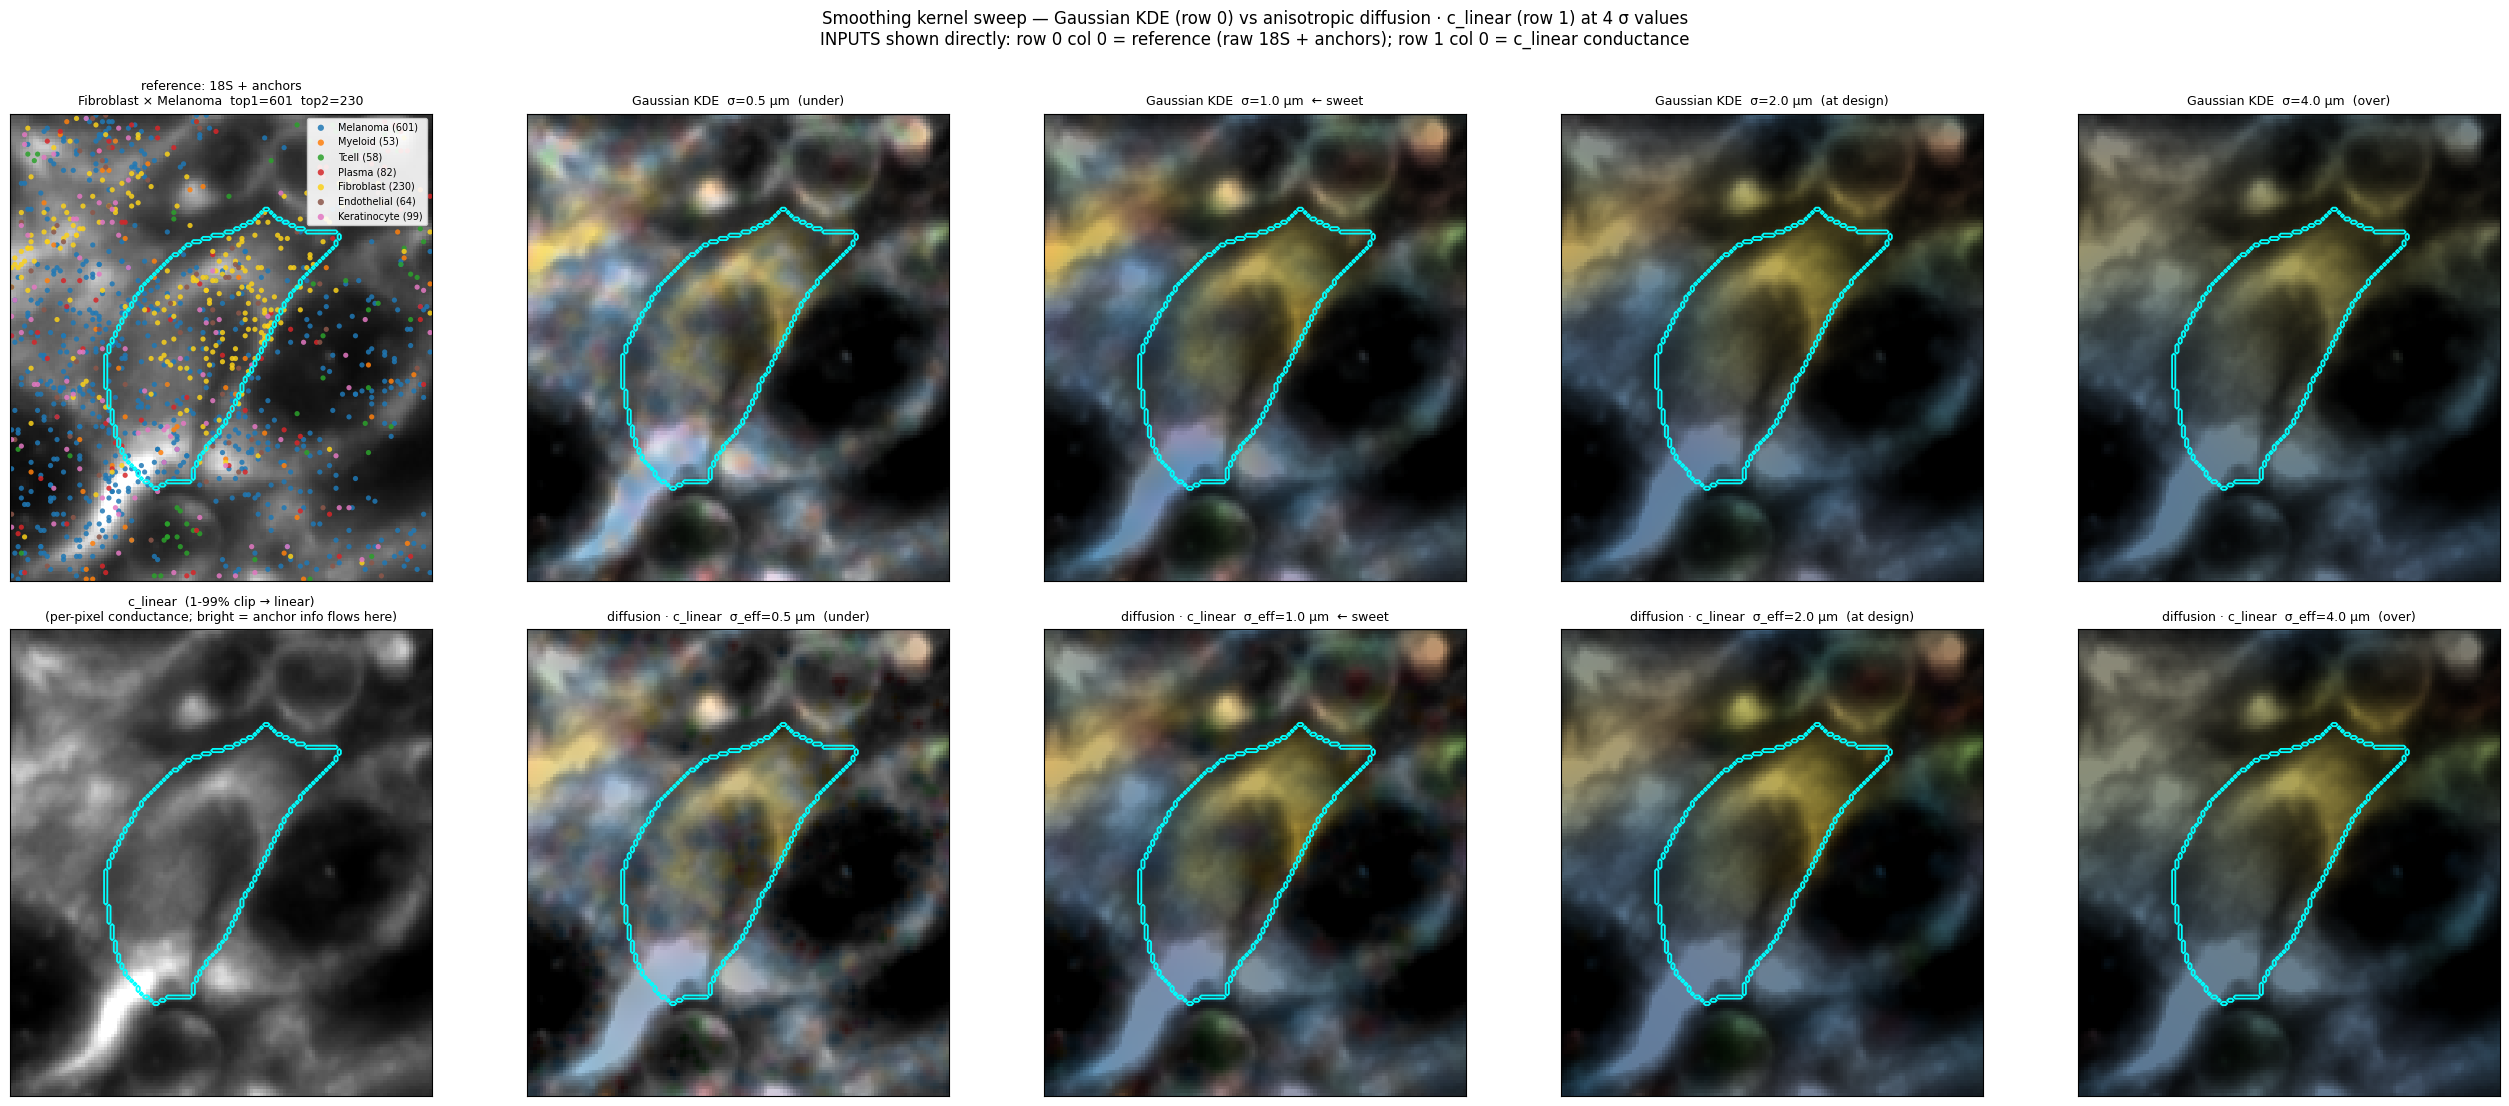

Zoomed in for clarity.


In [9]:
# 2 rows × 5 cols: reference + Gaussian × 4 σ on row 0; conductance + anisotropic × 4 σ on row 1
# Crop to focal zoom for visibility (matches the original "good stuff" plot)
fig, axes = plt.subplots(2, 5, figsize=(26, 11))

# Row 0, col 0: reference — 18S + colored anchors with per-lineage counts in title
axes[0,0].imshow(s18[zoom], cmap="gray", vmin=0, vmax=vmax_s18)
in_z = (py >= zy0) & (py < zy1) & (px >= zx0) & (px < zx1)
counts = []
for k, L in enumerate(lib.LINEAGES):
    m = in_z & (li == k)
    if m.any():
        axes[0,0].scatter(px[m] - zx0, py[m] - zy0, s=14, color=LIN_COLORS[k],
                          edgecolors="none", alpha=0.85, label=f"{L} ({int(m.sum())})")
        counts.append((L, int(m.sum())))
axes[0,0].contour(find_boundaries(focal_z, mode="outer").astype(int), levels=[0.5], colors="cyan", linewidths=1.3)
top_lin = sorted(counts, key=lambda kv: -kv[1])[:2]
title_ref = f"reference: 18S + anchors\n{lin_a} × {lin_b}  top1={top_lin[0][1]}  top2={top_lin[1][1] if len(top_lin)>1 else 0}"
axes[0,0].set_title(title_ref, fontsize=9)
axes[0,0].legend(loc="upper right", fontsize=7, markerscale=1.2, framealpha=0.9)

# Row 0, cols 1-4: Gaussian KDE at each sigma
for j, (sigma_um, label) in enumerate(zip(SIGMAS_UM, SIGMA_LABELS)):
    axes[0, 1+j].imshow(gauss_tinted[sigma_um][zoom])
    axes[0, 1+j].contour(find_boundaries(focal_z, mode="outer").astype(int), levels=[0.5], colors="cyan", linewidths=1.3)
    axes[0, 1+j].set_title(f"Gaussian KDE  σ={sigma_um} µm  {label}", fontsize=9)

# Row 1, col 0: conductance map (input to anisotropic)
axes[1,0].imshow(cond[zoom], cmap="gray", vmin=0, vmax=1)
axes[1,0].contour(find_boundaries(focal_z, mode="outer").astype(int), levels=[0.5], colors="cyan", linewidths=1.3)
axes[1,0].set_title("c_linear  (1-99% clip → linear)\n(per-pixel conductance; bright = anchor info flows here)", fontsize=9)

# Row 1, cols 1-4: anisotropic at each sigma_eff
for j, (sigma_um, label) in enumerate(zip(SIGMAS_UM, SIGMA_LABELS)):
    axes[1, 1+j].imshow(aniso_tinted[sigma_um][zoom])
    axes[1, 1+j].contour(find_boundaries(focal_z, mode="outer").astype(int), levels=[0.5], colors="cyan", linewidths=1.3)
    axes[1, 1+j].set_title(f"diffusion · c_linear  σ_eff={sigma_um} µm  {label}", fontsize=9)

for ax in axes.ravel(): ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Smoothing kernel sweep — Gaussian KDE (row 0) vs anisotropic diffusion · c_linear (row 1) at 4 σ values\n"
             "INPUTS shown directly: row 0 col 0 = reference (raw 18S + anchors); row 1 col 0 = c_linear conductance",
             fontsize=12, y=1.001)
plt.tight_layout(); plt.show()
print("Zoomed in for clarity.")


## Stage 4 — Posterior (Dirichlet + grey-abstain)

```
π_post[k] = (N_eff[k] + α) / (N_total + K · α)       # Dirichlet posterior
c         = N_total / (N_total + N_min)              # confidence ∈ [0, 1]
π_abst[k] = c · π_post[k] + (1−c) · (1/K)            # grey-abstain blend with uniform
```

**Magic numbers** (validated empirically; change with a reason):
- **α = 10** — Dirichlet concentration. Resists 2-transcript blips dominating: a single lineage-X anchor in a Fib-dominant pixel produces only a tiny perturbation. Earlier α=0.5 let blips drive argmax flicker.
- **N_min = 3** — grey-abstain threshold. Three effective anchors is the floor for trusting a lineage call. Below, π collapses toward uniform 1/K.
- **σ_diffuse = 2 µm** (≈ 9.4 px) — anchor smoothing scale, roughly matching cytoplasmic mRNA spread in Xenium FFPE.

**Production smoothing**: anisotropic diffusion (`lib.lineage_posterior_anisotropic`), with `n_iter ≈ 1772` (4× the naive σ²/dt to compensate for typical cell-interior c²≈0.25). Stage 3's isotropic Gaussian N_eff was a baseline for the Stage 3b sweep — **not** the production choice. Stages 5-6 use Stage 4's outputs.

In [10]:
alpha = lib.ALPHA; n_min = lib.N_MIN
# PRODUCTION posterior — anisotropic diffusion σ_target = 2 µm guided by 18S.
# Replaces the isotropic N_eff computed in Stage 3 (which is kept above only as a baseline
# for the Stage 3b sweep comparison). Downstream stages (5, 6) use these outputs.
import time; t = time.time()
pi_abst, confidence, N_eff = lib.lineage_posterior_anisotropic(
    py, px, li, H, W, s18,
    alpha=alpha, n_min=n_min,
    n_iter=lib.N_ITER_ANISO, dt=lib.DT_ANISO,
)
print(f"anisotropic posterior: n_iter={lib.N_ITER_ANISO}, dt={lib.DT_ANISO}, ran in {time.time()-t:.0f}s")
pi_abst = pi_abst.astype(np.float32)

print(f"pi_abst:    shape={pi_abst.shape}  range=[{pi_abst.min():.3f}, {pi_abst.max():.3f}]")
print(f"confidence: range=[{confidence.min():.3f}, {confidence.max():.3f}]  mean={confidence.mean():.3f}")
print(f"\nINSIDE focal cell {cps_focal}:")
print(f"  N_total mean = {N_eff.sum(0)[focal].mean():.1f}, max = {N_eff.sum(0)[focal].max():.1f}")
print(f"  confidence mean = {confidence[focal].mean():.3f}")
for k in (ka, kb):
    print(f"  π[{lib.LINEAGES[k]}]: min={pi_abst[k][focal].min():.3f}  max={pi_abst[k][focal].max():.3f}  mean={pi_abst[k][focal].mean():.3f}")


anisotropic posterior: n_iter=1772, dt=0.2, ran in 4s
pi_abst:    shape=(7, 384, 384)  range=[0.002, 0.986]
confidence: range=[0.000, 0.999]  mean=0.890

INSIDE focal cell 782:
  N_total mean = 209.4, max = 253.8
  confidence mean = 0.985
  π[Fibroblast]: min=0.080  max=0.572  mean=0.307
  π[Melanoma]: min=0.126  max=0.550  mean=0.351


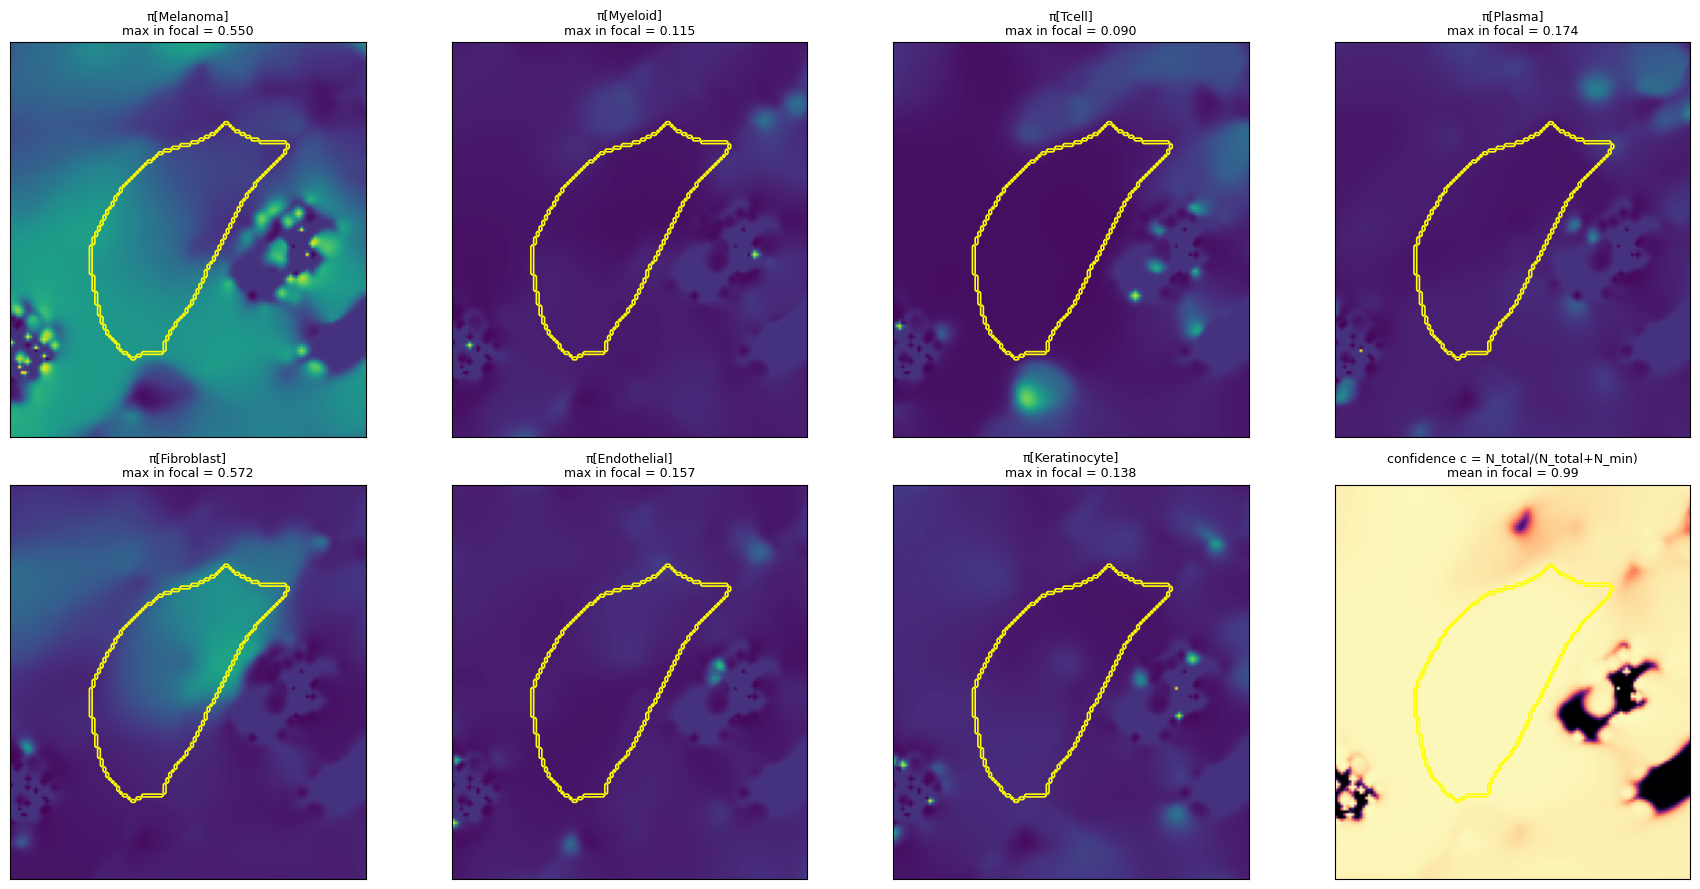

In [11]:
# Per-lineage pi_abst zoom on focal
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for k in range(K):
    axes.ravel()[k].imshow(pi_abst[k][zoom], cmap="viridis", vmin=0, vmax=pi_abst.max())
    axes.ravel()[k].contour(find_boundaries(focal_z, mode="outer").astype(int), levels=[0.5], colors="yellow", linewidths=1.2)
    axes.ravel()[k].set_title(f"π[{lib.LINEAGES[k]}]\nmax in focal = {pi_abst[k][focal].max():.3f}", fontsize=9)
axes[1,3].imshow(confidence[zoom], cmap="magma", vmin=0, vmax=1)
axes[1,3].contour(find_boundaries(focal_z, mode="outer").astype(int), levels=[0.5], colors="yellow", linewidths=1.2)
axes[1,3].set_title(f"confidence c = N_total/(N_total+N_min)\nmean in focal = {confidence[focal].mean():.2f}", fontsize=9)
for ax in axes.ravel(): ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## Stage 5 — Derived intensities: argmax, margin, cell_evidence

These are the inputs that downstream notebooks (boundary estimation, cutting) will consume.

In [12]:
top_idx  = np.argmax(pi_abst, axis=0).astype(np.int8)
top1_val = np.take_along_axis(pi_abst, top_idx[None].astype(np.int64), axis=0)[0]
masked   = np.where(np.arange(K, dtype=np.int8)[:, None, None] == top_idx[None], -np.inf, pi_abst)
top2_val = np.max(masked, axis=0)
margin   = (top1_val - top2_val).astype(np.float32)

# Cell evidence (morphology gate)
percentiles = lib.load_wsi_percentiles()
dapi_n = lib.clip01(dapi, percentiles["DAPI"]["q_lo"], percentiles["DAPI"]["q_hi"])
s18_n  = lib.clip01(s18,  percentiles["18S" ]["q_lo"], percentiles["18S" ]["q_hi"])
evidence = np.maximum(dapi_n, s18_n).astype(np.float32)

print(f"argmax label distribution across 2048 frame:")
for k, L in enumerate(lib.LINEAGES):
    print(f"  {L:14s}: {int((top_idx == k).sum()):>9,} px  ({(top_idx == k).mean()*100:5.1f}%)")
print(f"\nmargin (π_top1 − π_top2): mean={margin.mean():.3f}, p95={np.percentile(margin, 95):.3f}, max={margin.max():.3f}")
print(f"  inside focal: mean={margin[focal].mean():.3f}, max={margin[focal].max():.3f}")
print(f"\ncell_evidence (max DAPI_n, 18S_n): mean={evidence.mean():.3f}")
print(f"  inside focal: mean={evidence[focal].mean():.3f}, p95={np.percentile(evidence[focal], 95):.3f}")

argmax label distribution across 2048 frame:
  Melanoma      :   104,938 px  ( 71.2%)
  Myeloid       :     6,277 px  (  4.3%)
  Tcell         :     5,330 px  (  3.6%)
  Plasma        :     6,090 px  (  4.1%)
  Fibroblast    :    19,511 px  ( 13.2%)
  Endothelial   :     2,665 px  (  1.8%)
  Keratinocyte  :     2,645 px  (  1.8%)

margin (π_top1 − π_top2): mean=0.231, p95=0.476, max=0.983
  inside focal: mean=0.255, max=0.440

cell_evidence (max DAPI_n, 18S_n): mean=0.320
  inside focal: mean=0.328, p95=0.549


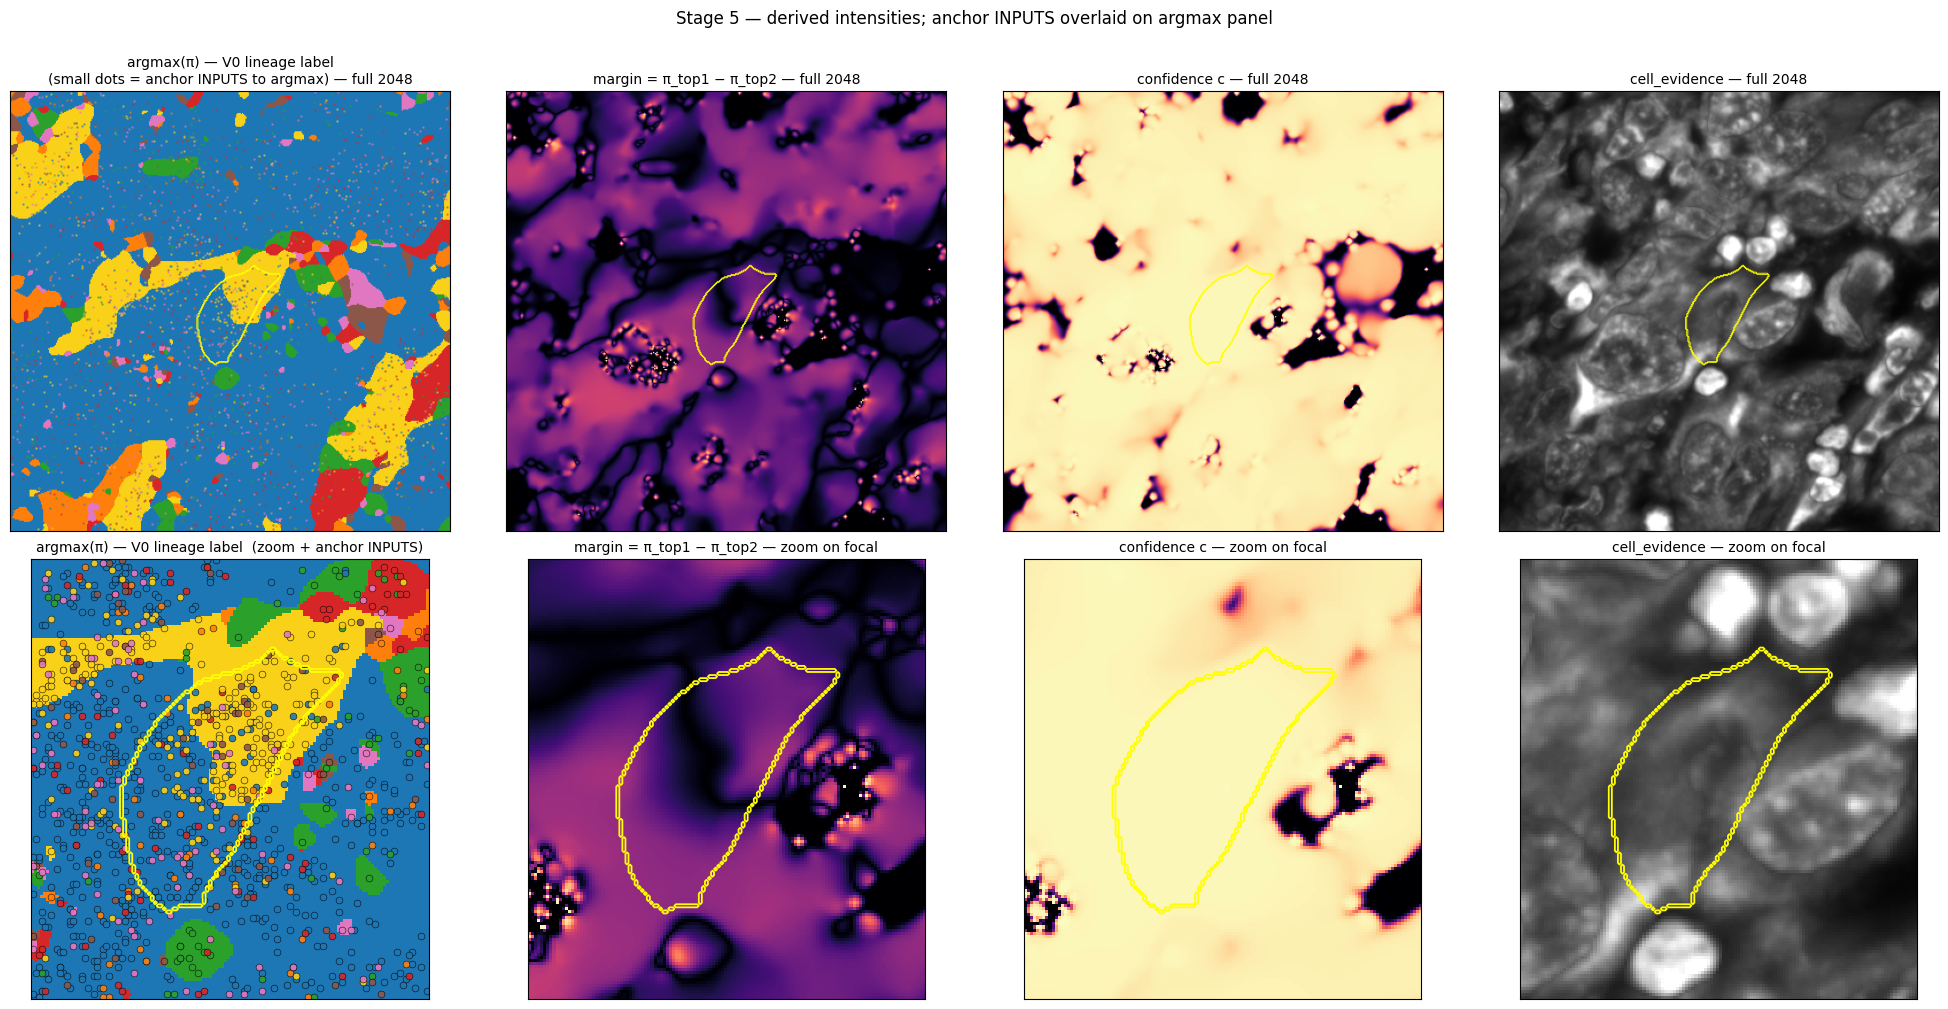

In [13]:
# Stage 5 summary — argmax / margin / confidence / cell_evidence at full 2048 + zoom
# INPUT (pi_abst): visible above in Stage 4. INPUT (anchors) overlaid on argmax panel below.
LIN_CMAP = ListedColormap([LIN_COLORS[k] for k in range(K)])
panels = [
    (top_idx,    "argmax(π) — V0 lineage label", LIN_CMAP, -0.5, K-0.5),
    (margin,     "margin = π_top1 − π_top2",      "magma",  0,    margin.max()),
    (confidence, "confidence c",                    "magma",  0,    1),
    (evidence,   "cell_evidence",                   "gray",   0,    1),
]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for j, (img, title, cmap, vmin, vmax) in enumerate(panels):
    axes[0,j].imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[0,j].contour(find_boundaries(focal, mode="outer").astype(int), levels=[0.5], colors="yellow", linewidths=0.6)
    if j == 0:
        # Overlay anchors on the argmax map at low alpha so the underlying label is still visible
        for k in range(K):
            m = li == k
            if m.any():
                axes[0,j].scatter(px[m], py[m], s=0.6, color=LIN_COLORS[k], alpha=0.5)
        axes[0,j].set_title(f"{title}\n(small dots = anchor INPUTS to argmax) — full 2048", fontsize=10)
    else:
        axes[0,j].set_title(f"{title} — full 2048", fontsize=10)
    axes[1,j].imshow(img[zoom], cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1,j].contour(find_boundaries(focal_z, mode="outer").astype(int), levels=[0.5], colors="yellow", linewidths=1.3)
    if j == 0:
        for k in range(K):
            m = in_z & (li == k)
            if m.any():
                axes[1,j].scatter(px[m] - zx0, py[m] - zy0, s=24, color=LIN_COLORS[k],
                                  edgecolors="black", linewidths=0.4, alpha=0.9)
        axes[1,j].set_title(f"{title}  (zoom + anchor INPUTS)", fontsize=10)
    else:
        axes[1,j].set_title(f"{title} — zoom on focal", fontsize=10)
for ax in axes.ravel(): ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Stage 5 — derived intensities; anchor INPUTS overlaid on argmax panel", fontsize=12, y=1.005)
plt.tight_layout(); plt.show()


## Stage 6 — Colored 18S (the actual tissue map we're producing)

This is the thing we're *actually colouring*: the 18S morphology channel with per-pixel lineage information painted on. Where 18S is bright, the lineage colour shows through. Where 18S is dark (inter-cell gaps), the pixel is black — nothing to cut there. Where confidence is low, we fall back to grayscale 18S so we don't pretend to know the lineage.

Without this view, everything downstream is abstract — boundaries and cuts are meaningless if you can't see the underlying coloured tissue they're operating on.

Composition:
```
s18_n     = clip01(s18, q_lo, q_hi)                 # brightness ∈ [0, 1]
color(x)  = LINEAGE_COLORS[argmax(π[x])]            # RGB triple
tinted    = color(x) · s18_n(x)                     # per-channel multiply
gray      = (s18_n, s18_n, s18_n)                   # grayscale fallback
colored_18s(x) = c(x) · tinted + (1 − c(x)) · gray  # low-conf → grayscale
```

Lineages (`lib.V0_LINEAGE_COLORS`): Mel=blue, Myeloid=orange, Tcell=green, Plasma=red, Fib=yellow, Endo=brown, Kerat=pink.

In [14]:
# Stage 6 colored 18S — BLENDED colors (per-pixel weighted sum over LIN_COLORS using pi_ml)
# NOT argmax: a pixel that is 60% Fib + 30% Mel + 10% other gets a per-channel blend, not pure purple.
LIN_COLORS = lib.V0_LINEAGE_COLORS
LIN_COLOR_ARRAY = np.array(LIN_COLORS[:lib.K], dtype=np.float32)

def make_colored_18s(s18, N_eff, confidence, color_array, low_pct=5, high_pct=95):
    """Blended coloured tissue map.

    Per-pixel colour = Σ_k pi_ml[k] · LIN_COLORS[k], where pi_ml = N_eff_k / N_total.
    Brightness from 18S local p5-p95 clip. Low-confidence pixels fall back to grayscale
    18S (NOT to the mean-of-colours which would muddy everything).
"
    """
    lo, hi = np.percentile(s18, [low_pct, high_pct])
    s18_n = np.clip((s18.astype(np.float32) - lo) / max(hi - lo, 1e-6), 0, 1)
    N_total = N_eff.sum(axis=0)
    pi_ml = N_eff / np.maximum(N_total, 1e-9)[None]
    color = np.einsum("khw,kc->hwc", pi_ml, color_array)                 # blended hue per pixel
    tinted = color * s18_n[..., None] * confidence[..., None]            # bright + colored in conf zones
    gray   = np.stack([s18_n, s18_n, s18_n], axis=-1) * (1.0 - confidence[..., None])
    return (tinted + gray).astype(np.float32)

colored_18s = make_colored_18s(s18, N_eff, confidence, LIN_COLOR_ARRAY)
print(f"colored_18s: shape={colored_18s.shape}, range=[{colored_18s.min():.3f}, {colored_18s.max():.3f}]")
print(f"  inside focal: per-channel mean = R {colored_18s[focal, 0].mean():.3f}  "
      f"G {colored_18s[focal, 1].mean():.3f}  B {colored_18s[focal, 2].mean():.3f}")


colored_18s: shape=(384, 384, 3), range=[0.000, 0.887]
  inside focal: per-channel mean = R 0.294  G 0.301  B 0.231


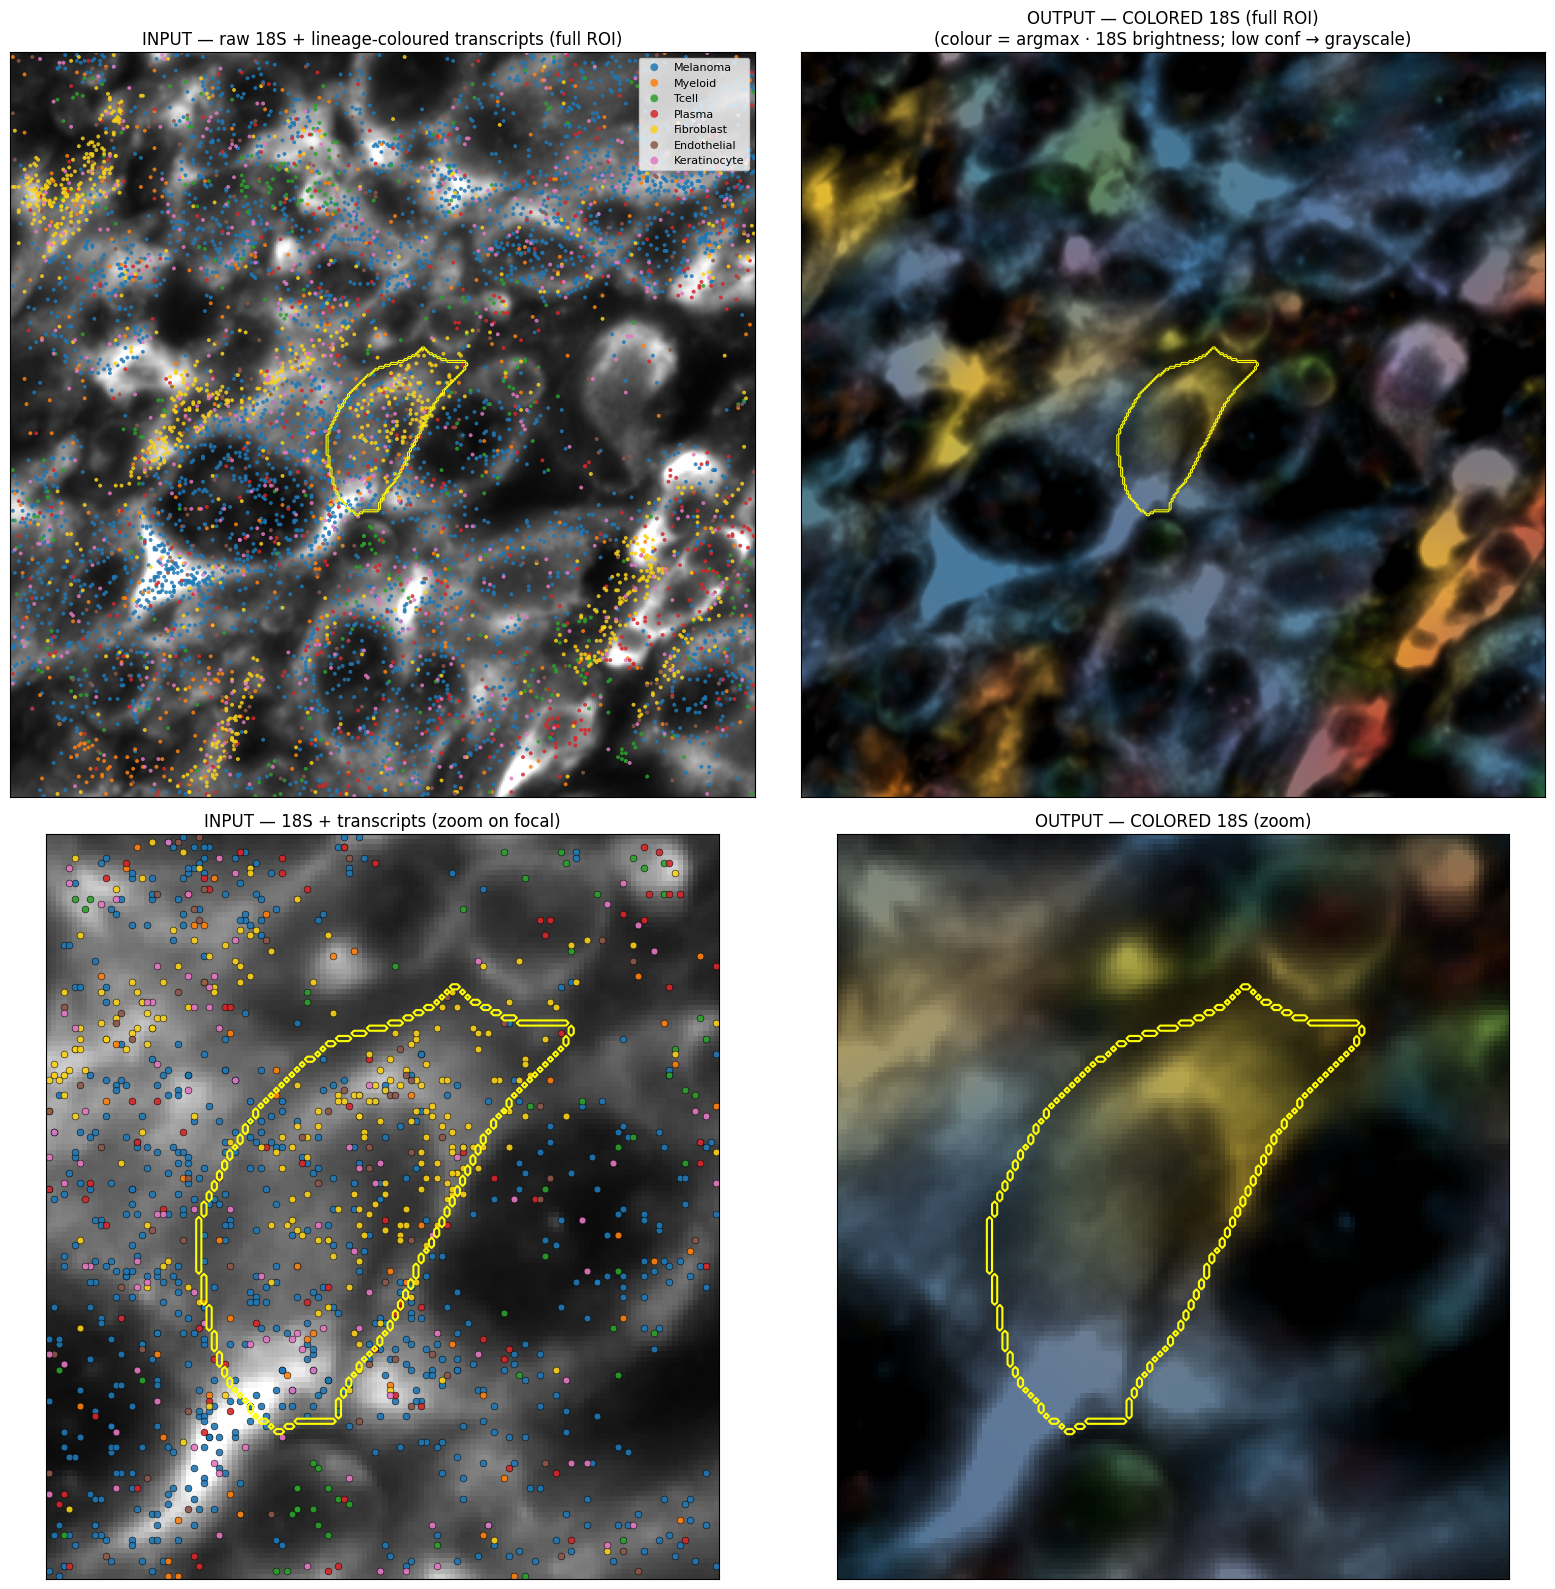

In [15]:
# Stage 6 visualisation — INPUT (raw 18S + lineage-coloured anchors) next to OUTPUT (colored 18S)
in_z = (py >= zy0) & (py < zy1) & (px >= zx0) & (px < zx1)
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# Row 0 — full ROI: input (18S + anchors) and output (colored 18S)
axes[0,0].imshow(s18, cmap="gray", vmin=0, vmax=vmax_s18)
for k, L in enumerate(lib.LINEAGES):
    m = li == k
    if m.any():
        axes[0,0].scatter(px[m], py[m], s=8, color=LIN_COLORS[k], edgecolors="none", alpha=0.85, label=L)
axes[0,0].contour(find_boundaries(focal, mode="outer").astype(int), levels=[0.5], colors="yellow", linewidths=0.8)
axes[0,0].set_title("INPUT — raw 18S + lineage-coloured transcripts (full ROI)")
axes[0,0].legend(loc="upper right", fontsize=8, markerscale=2)
axes[0,1].imshow(colored_18s)
axes[0,1].contour(find_boundaries(focal, mode="outer").astype(int), levels=[0.5], colors="yellow", linewidths=0.8)
axes[0,1].set_title("OUTPUT — COLORED 18S (full ROI)\n(colour = argmax · 18S brightness; low conf → grayscale)")

# Row 1 — zoom on focal: same input vs output
axes[1,0].imshow(s18[zoom], cmap="gray", vmin=0, vmax=vmax_s18)
for k, L in enumerate(lib.LINEAGES):
    m = in_z & (li == k)
    if m.any():
        axes[1,0].scatter(px[m] - zx0, py[m] - zy0, s=24, color=LIN_COLORS[k], edgecolors="black", linewidths=0.4, alpha=0.9)
axes[1,0].contour(find_boundaries(focal_z, mode="outer").astype(int), levels=[0.5], colors="yellow", linewidths=1.5)
axes[1,0].set_title("INPUT — 18S + transcripts (zoom on focal)")
axes[1,1].imshow(colored_18s[zoom])
axes[1,1].contour(find_boundaries(focal_z, mode="outer").astype(int), levels=[0.5], colors="yellow", linewidths=1.5)
axes[1,1].set_title("OUTPUT — COLORED 18S (zoom)")
for ax in axes.ravel(): ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


## Reading the colored 18S — what does the output mean?

Each pixel's color is the lineage-weighted blend of where anchor evidence places it, modulated by 18S brightness. Interpretations:

- A pure-Fib cell renders solid yellow; a pure-Mel cell solid blue.
- A heterotypic doublet shows a gradient with a transition zone (Mel↔Fib goes blue → green-ish → yellow).
- Where the cytoplasm goes dark (between cells), the pixel is dim regardless of lineage.
- Where anchor density is too low to call a lineage, the pixel falls back to grayscale 18S — no false confident color in empty stroma.

This is what NB 2 reads as background when evaluating boundary detectors.

## Failure modes — what to watch for

If any of these appear, fix the upstream stage before trusting the outputs:

- **Punctate points after diffusion** — anisotropic `n_iter` too low relative to typical cell c². Symptom: each anchor sits as an unspread dot rather than diffusing through its cell. Fix: increase `lib.ANISO_N_ITER_FACTOR` (currently 4, calibrated for c²≈0.25).
- **All-uniform π_abst (max < 0.20)** — α too large for this ROI's anchor density. Symptom: colored 18S uniform brownish everywhere. Fix: lower α (currently 10).
- **Anchors landing off-cell** — wrong coordinate frame. Caught by Stage 2's spatial-alignment sanity check (ratio of mean 18S at anchor vs. random < 1 is a red flag).
- **One lineage absurdly dominant** — gene-label table corrupted or wrong panel. Caught by Stage 1's marker-gene sanity (MITF→Mel, CD3E→Tcell, …).

## Output for NB 2 (boundary estimation)

When the validation checklist below passes, the following variables are the canonical inputs to NB 2:

- `pi_abst` — `(K, H, W) float32`, per-pixel lineage posterior
- `confidence` — `(H, W) float32` in [0, 1]
- `N_eff` — `(K, H, W) float32`, per-lineage smoothed counts

All three come from Stage 4 (anisotropic). NB 2 recomputes them from raw inputs (no cross-notebook variable passing) but using the same `lib.lineage_posterior_anisotropic` call, so consistency is mechanical.

## Validation checklist

Step through before moving to NB 2:

- [ ] **Marker-gene mapping** (Stage 1): MITF→Mel, CD3E→Tcell, CD79A→Plasma, CD14→Myeloid, PECAM1→Endo all correct.
- [ ] **Anchor count per lineage** is biologically reasonable for this ROI (no lineage absurdly over/under).
- [ ] **Anchors land on cells**: ratio of mean 18S at anchor / mean 18S at random ≳ 1.5×.
- [ ] **Anchors inside focal cell** show the expected lineage pair (Fib + Mel dominant for cell 031).
- [ ] **N_eff per-lineage maps** show high values where dense anchor clusters are; not flat or smeared too widely.
- [ ] **No punctate-points artifact** in the anisotropic panels (Stage 3b row 1).
- [ ] **π_abst max** inside focal is > 0.40 for the dominant lineage. If pinned near 1/K = 0.14, α too aggressive.
- [ ] **Confidence map** high inside cell bodies (>0.7), low in empty stroma (<0.3).
- [ ] **argmax map** colors cells correctly (Fib region yellow, Mel region blue, etc.).
- [ ] **cell_evidence** bright inside cells, dark in inter-cell gaps. Mean inside focal ≳ 0.15.
- [ ] **Colored 18S** at Stage 6 looks like properly-tinted cytoplasm, not muddy gray everywhere.

## Best practices — the canonical NB 1 recipe (what NB 2/NB 3/production use)

Everything above explores the design space. This cell is the **single recommended configuration** — copy-paste-ready for NB 2 and `pipelines/V0/00_run_pipeline.ipynb`.

```python
# --- Inputs (raw, segmentation-agnostic) ---
# DAPI:  tifffile.imread(dapi_path, key=0)         # NOT tf.series[0].asarray() — multi-file pyramid bug
# 18S:   tifffile.imread(s18_path,  key=0)
# tx:    transcripts.parquet with qv ≥ 20, valid == 1

# --- Gene → lineage ---
gene_lin = lib.load_lineage_label_map()              # int8, K=7 lineages
py, px, li = lib.load_anchors_in_bbox(y0, y1, x0, x1, gene_lin)

# --- Posterior (the production choice) ---
pi_abst, confidence, N_eff = lib.lineage_posterior_anisotropic(
    py, px, li, H, W, s18_raw,
    alpha=10,            # Dirichlet concentration — resists 1-2 anchor blips
    n_min=3,             # grey-abstain threshold
    conductance_mode='linear',   # c(p) from 1-99% clip of s18_raw
    # n_iter, dt come from lib.N_ITER_ANISO, lib.DT_ANISO
    # calibrated via ANISO_N_ITER_FACTOR=4 for typical cell c²≈0.25
)
# Effective σ ≈ 2 µm (≈ 9.4 px at Xenium 0.2125 µm/px) in cell interior.
```

**Hand to NB 2:** `pi_abst`, `confidence`, `N_eff`. Recompute from raw — do NOT cache intermediates across notebooks.

### Anti-patterns (do NOT use)
- **Isotropic Gaussian KDE** for the production posterior — leaks across 18S gaps.
- **α < 5** — single-transcript blips drive argmax flicker.
- **pi_abst for the colored 18S blend** — α=10 mutes saturation. Use `pi_ml = N_eff/N_total` for visualisation only.
- **`plt.cm.tab10`** for lineage colors — puts Mel-blue next to Fib-purple. Use `lib.V0_LINEAGE_COLORS` (Fib=yellow).
- **Log-scaled 18S** anywhere (viz or analysis). Linear with local p5-p95 only.
- **WSI-cached `q_lo`/`q_hi`** for local viz brightness — under-brights typical crops. Use local p5-p95.
- **2048 px ROI** for NB 1 — no CP-SAM, so 384 px is the right working size.
